In [4]:
import pandas as pd

In [5]:
df= pd.read_csv(r"C:\Users\Naren karthikeyan\Downloads\Project-2\monthly_business_metrics.csv")
df.head()


,months,revenue,orders,customers,quantity,avg_price
0,2009-12-01,825685.76,1682,955,426981,4.27
1,2010-01-01,652708.50,1105,720,391525,4.63
2,2010-02-01,553713.31,1202,772,382782,3.78
3,2010-03-01,833570.13,1681,1057,527401,5.13
4,2010-04-01,681528.99,1462,942,368198,4.35


In [6]:
df['AOV'] = df['revenue'] / df['orders']

df['qty_per_order'] = df['quantity'] / df['orders']

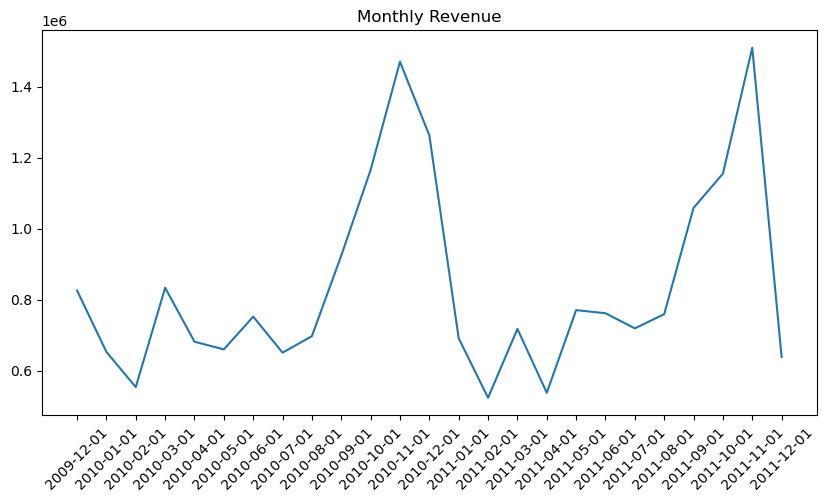

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df['months'], df['revenue'])

plt.xticks(rotation=45)

plt.title('Monthly Revenue')

plt.show()

In [6]:
# there is an major spike in the revenue in every 7 month of the year and the revenue drops drastically and 11th month of every years it shows an seasonal activity
#but only with 2 years years of data i cannot say it an season

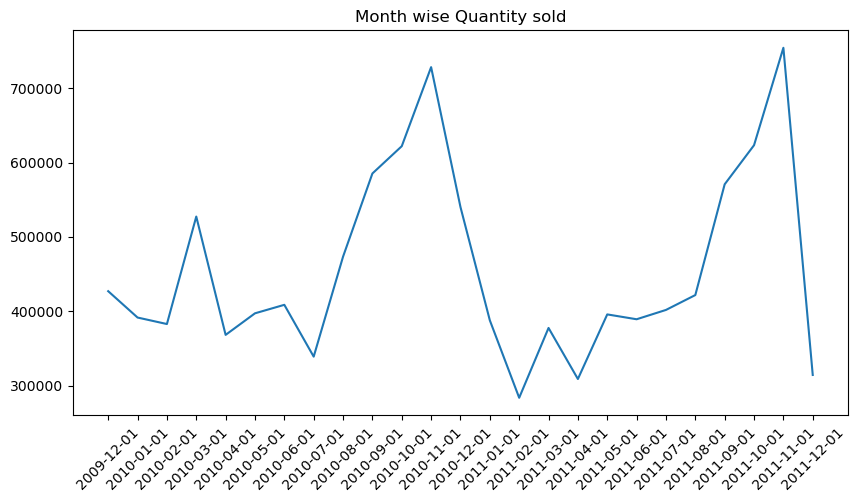

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df['months'], df['quantity'])

plt.xticks(rotation=45)

plt.title('Month wise Quantity sold')

plt.show()

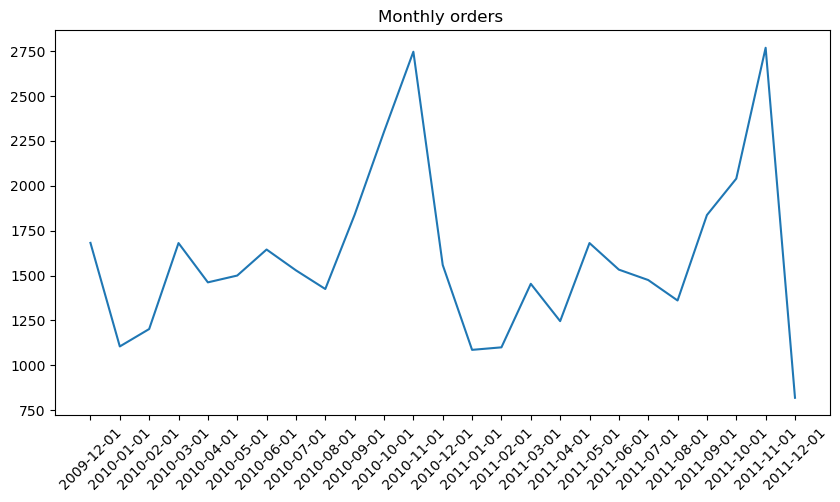

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df['months'], df['orders'])

plt.xticks(rotation=45)

plt.title('Monthly orders ')

plt.show()

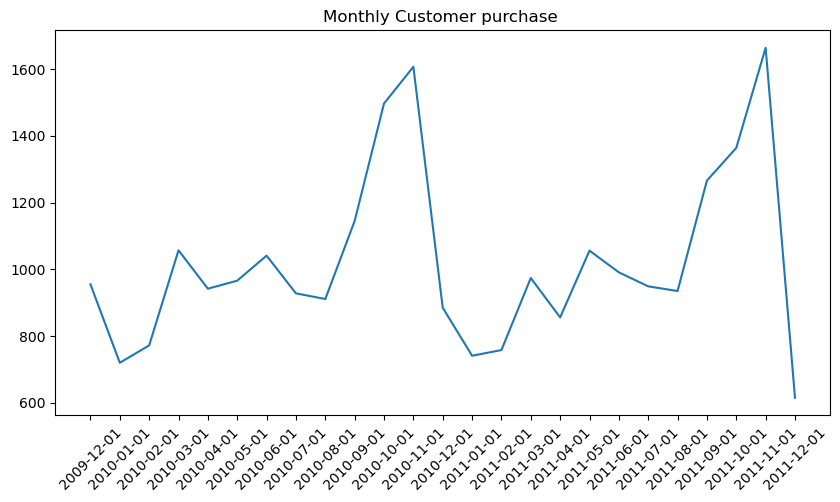

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df['months'], df['customers'])

plt.xticks(rotation=45)

plt.title('Monthly Customer purchase ')

plt.show()

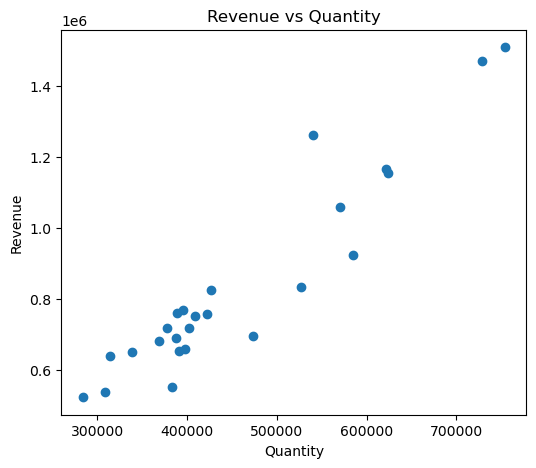

In [10]:
plt.figure(figsize=(6,5))

plt.scatter(df['quantity'], df['revenue'])

plt.xlabel('Quantity')

plt.ylabel('Revenue')

plt.title('Revenue vs Quantity')

plt.show()

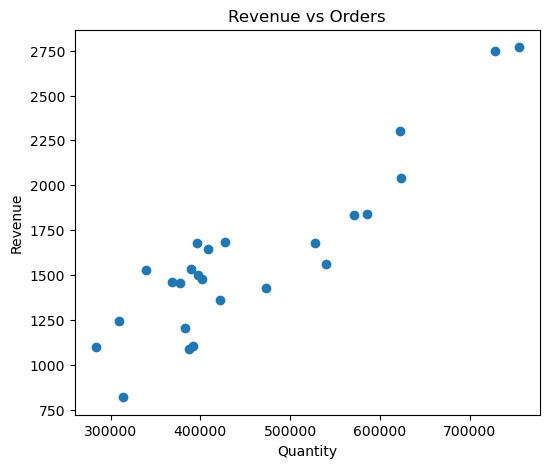

In [11]:
plt.figure(figsize=(6,5))

plt.scatter(df['quantity'], df['orders'])

plt.xlabel('Quantity')

plt.ylabel('Revenue')

plt.title('Revenue vs Orders')

plt.show()

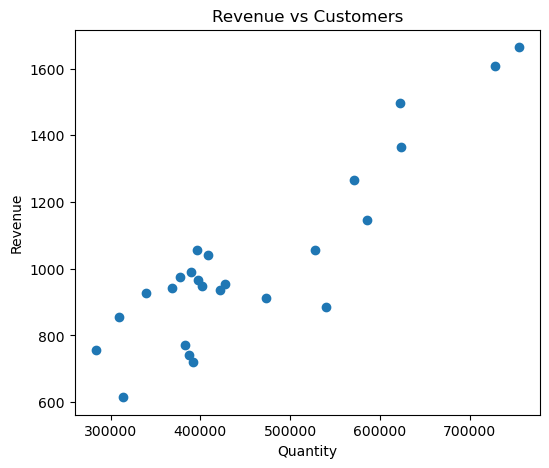

In [12]:
plt.figure(figsize=(6,5))

plt.scatter(df['quantity'], df['customers'])

plt.xlabel('Quantity')

plt.ylabel('Revenue')

plt.title('Revenue vs Customers')

plt.show()

In [14]:
corr_matrix = df.corr(numeric_only=True)

corr_matrix

,revenue,orders,customers,quantity,avg_price,AOV,qty_per_order
revenue,1.000000,0.885075,0.858552,0.941378,-0.082741,0.325003,0.028593
orders,0.885075,1.000000,0.980256,0.899980,-0.167115,-0.139146,-0.334991
customers,0.858552,0.980256,1.000000,0.891821,-0.234494,-0.149795,-0.314322
quantity,0.941378,0.899980,0.891821,1.000000,-0.094124,0.173113,0.093815
avg_price,-0.082741,-0.167115,-0.234494,-0.094124,1.000000,0.156406,0.137813
AOV,0.325003,-0.139146,-0.149795,0.173113,0.156406,1.000000,0.763952
qty_per_order,0.028593,-0.334991,-0.314322,0.093815,0.137813,0.763952,1.000000


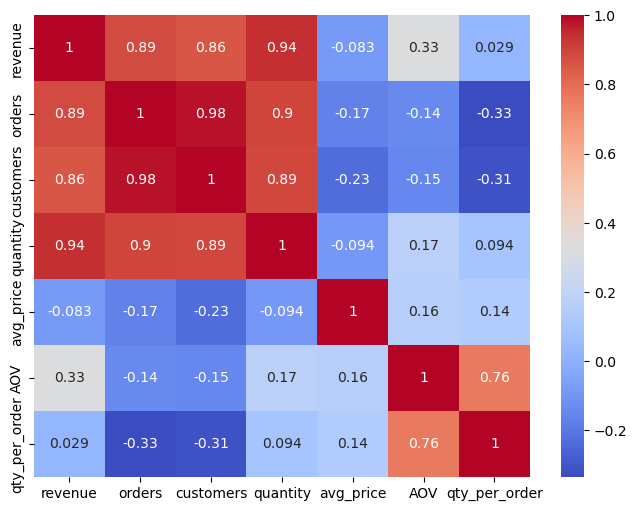

In [15]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [16]:
from scipy.stats import pearsonr
#verfying that the correlations are not some random patterns but they actually exists if p_value <0.05 
#else they are random 

In [17]:
corr, p_value = pearsonr(df['orders'], df['revenue'])

print(corr)
print(f"{p_value:.12f}")

0.8850747668487384
0.000000004224


In [18]:
corr, p_value = pearsonr(df['customers'], df['revenue'])

print(corr)
print(f"{p_value:.12f}")

0.8585516179996714
0.000000040176


In [19]:
corr, p_value = pearsonr(df['quantity'], df['revenue'])

print(corr)
print(f"{p_value:.12f}")

0.9413780819963626
0.000000000002


In [20]:
corr, p_value = pearsonr(df['avg_price'], df['revenue'])
print(f"{p_value:.12f}")


0.694172996492


In [21]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = df[
    [
        'orders',
        'customers',
        'quantity',
        'avg_price'
    ]
]
vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif)

    Variable         VIF
0     orders  334.292803
1  customers  356.920475
2   quantity   77.776302
3  avg_price   14.006785


In [22]:
# As the VIF are still terrible 
"""
1 - good 
<5 - okish
5-10 - moderate problem
> 10 worst 
"""
# we shall not proceed with regression 

'\n1 - good \n<5 - okish\n5-10 - moderate problem\n> 10 worst \n'

In [23]:
df1=pd.read_csv(r"C:\Users\Naren karthikeyan\Downloads\online+retail+ii\online_retail_II.csv",encoding="latin1")
df2 = pd.read_csv(r"C:\Users\Naren karthikeyan\Downloads\online+retail+ii\online_retail_II1.csv",encoding="latin1")
df3 = pd.concat([df1, df2], ignore_index=True)
df1.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01-12-2009 07:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,01-12-2009 07:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01-12-2009 07:45,1.25,13085.0,United Kingdom


In [24]:
df1.dtypes

Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object

In [25]:
print(df3.columns.tolist())


['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [26]:
df3['Revenue']=df3["Quantity"]*df3["Price"]

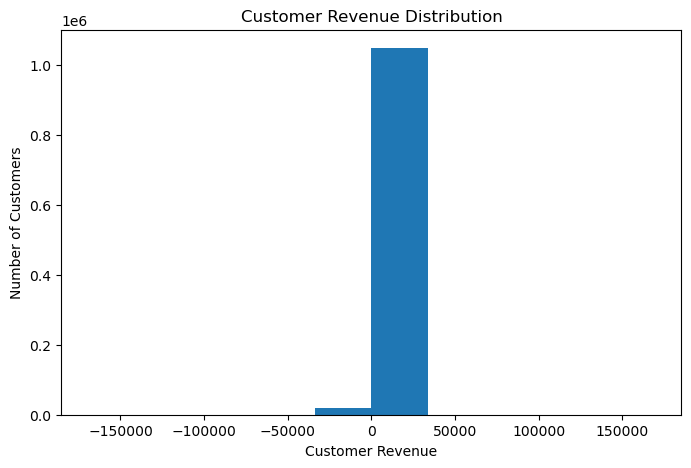

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df3["Revenue"], bins=10)

plt.xlabel("Customer Revenue")
plt.ylabel("Number of Customers")

plt.title("Customer Revenue Distribution")

plt.show()

In [28]:
df3.describe()

,Quantity,Price,Customer ID,Revenue
count,1.067371e+06,1.067371e+06,824364.000000,1.067371e+06
mean,9.938898e+00,4.649388e+00,15324.638504,1.806987e+01
std,1.727058e+02,1.235531e+02,1697.464450,2.924202e+02
min,-8.099500e+04,-5.359436e+04,12346.000000,-1.684696e+05
25%,1.000000e+00,1.250000e+00,13975.000000,3.750000e+00
50%,3.000000e+00,2.100000e+00,15255.000000,9.900000e+00
75%,1.000000e+01,4.150000e+00,16797.000000,1.770000e+01
max,8.099500e+04,3.897000e+04,18287.000000,1.684696e+05


In [29]:
customer_df = df3.copy()


In [30]:
customer_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01-12-2009 07:45,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,01-12-2009 07:45,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01-12-2009 07:45,1.25,13085.0,United Kingdom,30.0


In [31]:
customer_df = customer_df.sort_values(
    by='Revenue',
    ascending=False
)

In [32]:
customer_df['cum_revenue'] = customer_df['Revenue'].cumsum()

total_revenue = customer_df['Revenue'].sum()

customer_df['cum_pct_revenue'] = (
    customer_df['cum_revenue'] / total_revenue
) * 100

In [33]:
customer_df['customer_percentile'] = (
    customer_df.index + 1
) / len(customer_df) * 100

In [34]:
top_1 = customer_df.head(
    int(len(customer_df)*0.01)
)['Revenue'].sum()

top_5 = customer_df.head(
    int(len(customer_df)*0.05)
)['Revenue'].sum()

top_10 = customer_df.head(
    int(len(customer_df)*0.10)
)['Revenue'].sum()

top_20 = customer_df.head(
    int(len(customer_df)*0.20)
)['Revenue'].sum()

total_revenue = customer_df['Revenue'].sum()

print("Top 1%:", round(top_1/total_revenue*100,2))
print("Top 5%:", round(top_5/total_revenue*100,2))
print("Top 10%:", round(top_10/total_revenue*100,2))
print("Top 20%:", round(top_20/total_revenue*100,2))

Top 1%: 27.01
Top 5%: 48.53
Top 10%: 60.12
Top 20%: 73.69


In [35]:
customer_df = customer_df.sort_values(
    by='Revenue'
)

In [39]:
import numpy as np
customer_df['cum_customer_pct'] = (
    np.arange(1,len(customer_df)+1)
    / len(customer_df)
)

customer_df['cum_revenue_pct'] = (
    customer_df['Revenue'].cumsum()
    / customer_df['Revenue'].sum()
)

In [40]:
customer_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,cum_revenue,cum_pct_revenue,customer_percentile,cum_customer_pct,cum_revenue_pct
1065883,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,09-12-2011 09:27,2.08,16446.0,United Kingdom,-168469.60,1.928725e+07,100.000000,99.860686,9.368814e-07,-0.008735
587085,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,18-01-2011 10:17,1.04,12346.0,United Kingdom,-77183.60,1.945572e+07,100.873476,55.002993,1.873763e-06,-0.012737
179403,A506401,B,Adjust bad debt,1,29-04-2010 13:36,-53594.36,NaN,United Kingdom,-53594.36,1.953290e+07,101.273656,16.808026,2.810644e-06,-0.015515
276274,A516228,B,Adjust bad debt,1,19-07-2010 11:24,-44031.79,NaN,United Kingdom,-44031.79,1.958650e+07,101.551530,25.883690,3.747525e-06,-0.017798
748142,C556445,M,Manual,-1,10-06-2011 15:31,38970.00,15098.0,United Kingdom,-38970.00,1.963053e+07,101.779825,70.092124,4.684407e-06,-0.019819


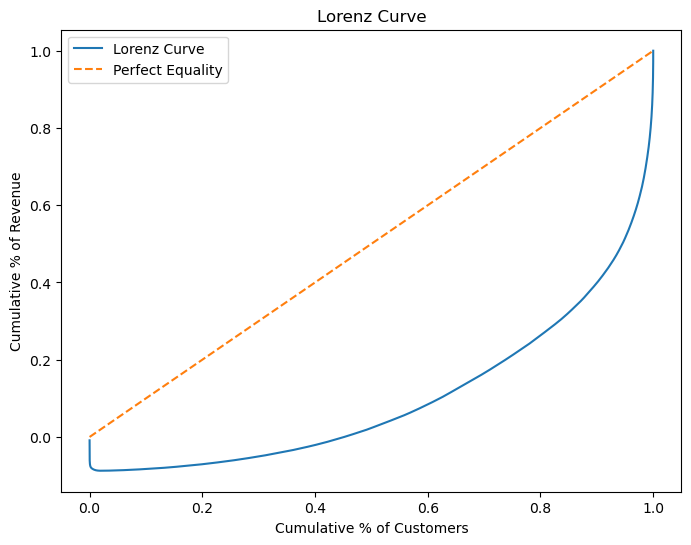

In [41]:
plt.figure(figsize=(8,6))

# Lorenz curve
plt.plot(
    customer_df['cum_customer_pct'],
    customer_df['cum_revenue_pct'],
    label='Lorenz Curve'
)

# Equality line
plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    label='Perfect Equality'
)

plt.xlabel('Cumulative % of Customers')

plt.ylabel('Cumulative % of Revenue')

plt.title('Lorenz Curve')

plt.legend()

plt.show()

In [42]:
from scipy.integrate import trapezoid

x = customer_df['cum_customer_pct']
y = customer_df['cum_revenue_pct']

area_under_curve = trapezoid(y, x)

gini = 1 - 2*area_under_curve

print(round(gini,3))

0.8


In [43]:
threshold = customer_df['Revenue'].quantile(0.90)

customer_df['segment'] = customer_df['Revenue'].apply(
    lambda x: 'Top 10%' if x >= threshold else 'Bottom 90%'
)

In [44]:
customer_df.dtypes

Invoice                 object
StockCode               object
Description             object
Quantity                 int64
InvoiceDate             object
Price                  float64
Customer ID            float64
Country                 object
Revenue                float64
cum_revenue            float64
cum_pct_revenue        float64
customer_percentile    float64
cum_customer_pct       float64
cum_revenue_pct        float64
segment                 object
dtype: object

In [45]:
total_revenue = customer_df['Revenue'].sum()

# 2. Count the number of UNIQUE orders (Invoices)
total_orders = customer_df['Invoice'].nunique()

# 3. Calculate Average Order Value (AOV)
customer_df['AOV'] = total_revenue / total_orders

In [46]:
min(customer_df['InvoiceDate'])

'01-02-2010 08:13'

In [47]:

customer_df['InvoiceDate'] = pd.to_datetime(
    customer_df['InvoiceDate'], 
    dayfirst=True, 
    errors='coerce'
)

# Calculate your lifespan columns directly inside the existing dataframe
customer_df['First_Purchase'] = customer_df.groupby('Customer ID')['InvoiceDate'].transform('min')
customer_df['Last_Purchase'] = customer_df.groupby('Customer ID')['InvoiceDate'].transform('max')
customer_df['Lifespan_Days'] = (customer_df['Last_Purchase'] - customer_df['First_Purchase']).dt.days

customer_df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,cum_revenue,cum_pct_revenue,customer_percentile,cum_customer_pct,cum_revenue_pct,segment,AOV,First_Purchase,Last_Purchase,Lifespan_Days
1065883,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom,-168469.60,1.928725e+07,100.000000,99.860686,9.368814e-07,-0.008735,Bottom 90%,359.648888,2010-10-04 16:38:00,2011-12-09 09:27:00,430.0
587085,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346.0,United Kingdom,-77183.60,1.945572e+07,100.873476,55.002993,1.873763e-06,-0.012737,Bottom 90%,359.648888,2009-12-14 08:34:00,2011-01-18 10:17:00,400.0
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom,-53594.36,1.953290e+07,101.273656,16.808026,2.810644e-06,-0.015515,Bottom 90%,359.648888,NaT,NaT,NaN
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom,-44031.79,1.958650e+07,101.551530,25.883690,3.747525e-06,-0.017798,Bottom 90%,359.648888,NaT,NaT,NaN
748142,C556445,M,Manual,-1,2011-06-10 15:31:00,38970.00,15098.0,United Kingdom,-38970.00,1.963053e+07,101.779825,70.092124,4.684407e-06,-0.019819,Bottom 90%,359.648888,2011-06-10 15:22:00,2011-06-10 15:39:00,0.0


In [48]:
customer_df['Orders'] = customer_df.groupby('Customer ID')['Invoice'].transform('nunique')

In [57]:
comparison = customer_df.groupby('segment')[
[
    'Orders',
    'Quantity',
    'AOV',
    'Lifespan_Days'
]
].mean()

print(comparison)

               Orders   Quantity       AOV  Lifespan_Days
segment                                                  
Bottom 90%  39.621751   5.029890  1.278113     504.402336
Top 10%     58.442442  53.492989  8.542602     572.365937


In [59]:
from scipy.stats import ttest_ind

top = customer_df[
    customer_df['segment']=='Top 10%'
]

bottom = customer_df[
    customer_df['segment']=='Bottom 90%'
]

ttest_ind(
    top['Orders'],
    bottom['Orders'],
    equal_var=False
)

TtestResult(statistic=np.float64(nan), pvalue=np.float64(nan), df=np.float64(nan))

In [55]:
customer_df['AOV'] = (
    customer_df['Revenue']
    /
    customer_df['Orders']
)

In [62]:
customer_df.isnull().sum()

Invoice                     0
StockCode                   0
Description              4382
Quantity                    0
InvoiceDate                 0
Price                       0
Customer ID            243007
Country                     0
Revenue                     0
cum_revenue                 0
cum_pct_revenue             0
customer_percentile         0
cum_customer_pct            0
cum_revenue_pct             0
segment                     0
AOV                    243007
First_Purchase         243007
Last_Purchase          243007
Lifespan_Days          243007
Orders                 243007
dtype: int64

In [63]:
import numpy as np

np.isinf(top[['Orders','Quantity','AOV','Lifespan_Days']]).sum()

np.isinf(bottom[['Orders','Quantity','AOV','Lifespan_Days']]).sum()

Orders           0
Quantity         0
AOV              0
Lifespan_Days    0
dtype: int64

In [64]:
top = customer_df[
    customer_df['segment']=='Top 10%'
]

bottom = customer_df[
    customer_df['segment']=='Bottom 90%'
]

In [70]:
from scipy.stats import ttest_ind

ttest_ind(
    top['Orders'].dropna(),
    bottom['Orders'].dropna(),
    equal_var=False
)

TtestResult(statistic=np.float64(61.11212096740859), pvalue=np.float64(0.0), df=np.float64(116751.57154632197))

In [67]:
print(len(top))
print(len(bottom))

108118
959253


In [68]:
top.dtypes

Invoice                        object
StockCode                      object
Description                    object
Quantity                        int64
InvoiceDate            datetime64[ns]
Price                         float64
Customer ID                   float64
Country                        object
Revenue                       float64
cum_revenue                   float64
cum_pct_revenue               float64
customer_percentile           float64
cum_customer_pct              float64
cum_revenue_pct               float64
segment                        object
AOV                           float64
First_Purchase         datetime64[ns]
Last_Purchase          datetime64[ns]
Lifespan_Days                 float64
Orders                        float64
dtype: object

In [71]:
ttest_ind(
top['Quantity'].dropna(),
bottom['Quantity'].dropna(),
equal_var=False
)

TtestResult(statistic=np.float64(40.69146960856365), pvalue=np.float64(0.0), df=np.float64(110681.72856419443))

In [72]:
ttest_ind(
top['AOV'].dropna(),
bottom['AOV'].dropna(),
equal_var=False
)

TtestResult(statistic=np.float64(15.302001380300034), pvalue=np.float64(8.52239565607186e-53), df=np.float64(99071.61661782955))

In [73]:
ttest_ind(
top['Lifespan_Days'].dropna(),
bottom['Lifespan_Days'].dropna(),
equal_var=False
)

TtestResult(statistic=np.float64(94.07428876009756), pvalue=np.float64(0.0), df=np.float64(128618.85671541705))

In [1]:
#Time series Forcating 

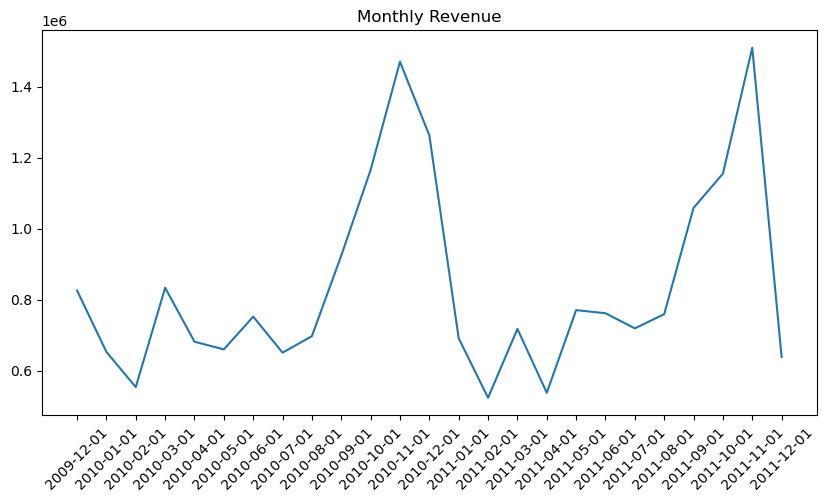

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df['months'], df['revenue'])

plt.xticks(rotation=45)

plt.title('Monthly Revenue')

plt.show()

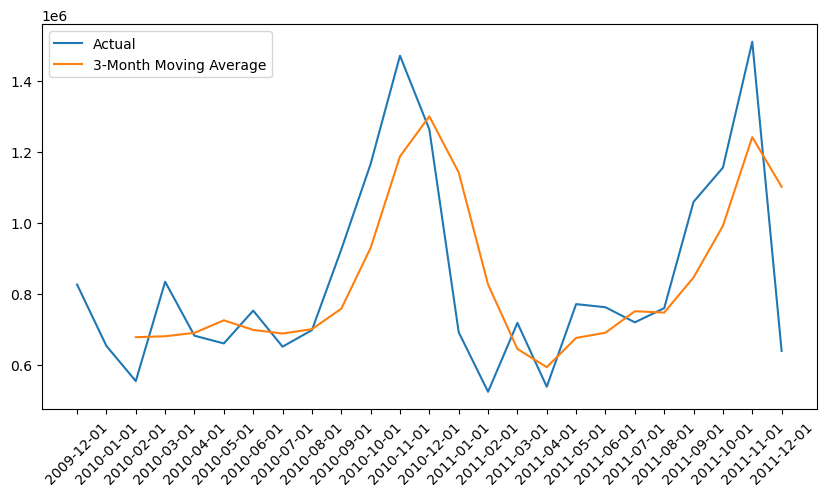

In [16]:
df['MA_3'] = (
    df['revenue']
    .rolling(3)
    .mean()
)

plt.figure(figsize=(10,5))

plt.plot(
    df['months'],
    df['revenue'],
    label='Actual'
)


plt.plot(
    df['months'],
    df['MA_3'],
    label='3-Month Moving Average'
)
plt.xticks(rotation=45)
plt.legend()

plt.show()

In [19]:
# Anomaly detection 

In [20]:
df['z_score'] = (
df['revenue']
    -
    df['revenue'].mean()
) / df['revenue'].std()

In [21]:
df[
    abs(df['z_score']) > 2
]

,months,revenue,orders,customers,quantity,avg_price,AOV,qty_per_order,MA_3,z_score
11,2010-11-01,1470272.48,2747,1607,728449,3.7,535.228424,265.179833,1.186696e+06,2.290258
23,2011-11-01,1509496.33,2769,1664,754507,3.6,545.141325,272.483568,1.241022e+06,2.432543
